<a href="https://colab.research.google.com/github/GuilhermeHRDS/AnaliseExploratoria/blob/main/Atividade_pr%C3%A1tica_4840505.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Nome: Guilherme Henrique Rodrigues da Silva

RU: 4840505

Curso: Ciências de Dados

In [6]:
!pip install bokeh_sampledata

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.7/17.7 MB 66.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.4/442.4 kB 27.9 MB/s eta 0:00:00


In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from bokeh.sampledata.iris import flowers as data

df = data.copy()

In [26]:
# Primeiras linhas
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [24]:
#Dimensão do dataFrame
df.shape

(150, 5)

In [23]:
# Tipos dos dados
df.dtypes

,0
sepal_length,float64
sepal_width,float64
petal_length,float64
petal_width,float64
species,object


In [25]:
# Nome das Colunas
df.columns

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='object')

In [29]:
#Resumo estatístico
display(df.describe())

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [32]:
# Frequência Absoluta
freq_abs = df['species'].value_counts()
print(freq_abs)

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


In [33]:
# Frequência Relativa
freq_rel = df['species'].value_counts(normalize=True)
print(freq_rel)

species
setosa        0.333333
versicolor    0.333333
virginica     0.333333
Name: proportion, dtype: float64


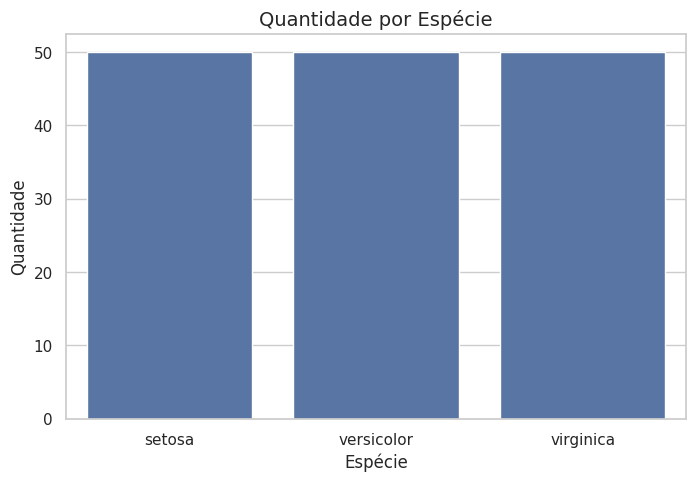

In [41]:
#Gráfico de barras (Total por espécies)

plt.figure(figsize=(8,5))
sns.barplot(x=freq_abs.index, y=freq_abs.values)

plt.title('Quantidade por Espécie', fontsize=14)
plt.xlabel('Espécie')
plt.ylabel('Quantidade')


plt.show()

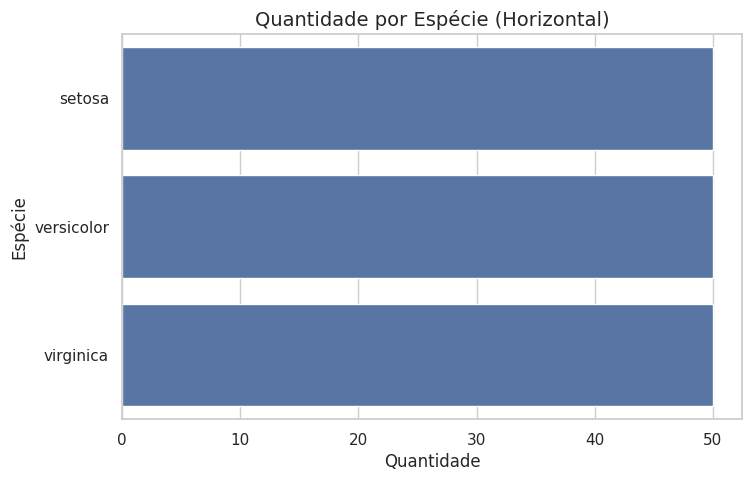

In [43]:
# Gráfico Horizontal
plt.figure(figsize=(8,5))
sns.barplot(x=freq_abs.values, y=freq_abs.index)

plt.title('Quantidade por Espécie (Horizontal)', fontsize=14)
plt.xlabel('Quantidade')
plt.ylabel('Espécie')


plt.show()

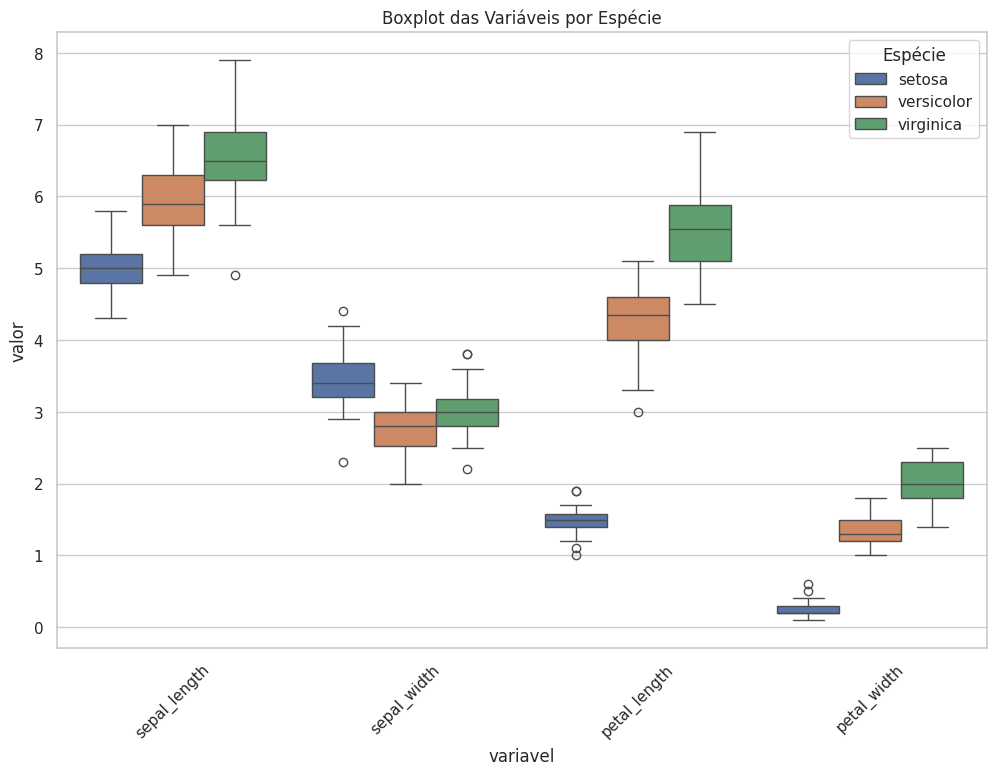

In [44]:
#7 - Exiba bloxplot do dataset (mostrando de todas as colunas, por espécies)

plt.figure(figsize=(12,8))
df_melt = df.melt(id_vars='species', var_name='variavel', value_name='valor')

sns.boxplot(x='variavel', y='valor', hue='species', data=df_melt)

plt.title('Boxplot das Variáveis por Espécie')
plt.xticks(rotation=45)
plt.legend(title='Espécie')

plt.show()

In [47]:
#8 - Calcule a média e mediana agrupadas por espécies

media_mediana = df.groupby('species').agg(['mean', 'median'])
display(media_mediana)

sepal_length        sepal_width        petal_length         \
                   mean median        mean median         mean median   
species                                                                 
setosa            5.006    5.0       3.428    3.4        1.462   1.50   
versicolor        5.936    5.9       2.770    2.8        4.260   4.35   
virginica         6.588    6.5       2.974    3.0        5.552   5.55   

           petal_width         
                  mean median  
species                        
setosa           0.246    0.2  
versicolor       1.326    1.3  
virginica        2.026    2.0

In [46]:
# 9 - Calcule o desvio padrão e a variância agrupadas por espécies

desvio_variancia = df.groupby('species').agg(['std', 'var'])
display(desvio_variancia)

sepal_length           sepal_width           petal_length  \
                    std       var         std       var          std   
species                                                                
setosa         0.352490  0.124249    0.379064  0.143690     0.173664   
versicolor     0.516171  0.266433    0.313798  0.098469     0.469911   
virginica      0.635880  0.404343    0.322497  0.104004     0.551895   

                     petal_width            
                 var         std       var  
species                                     
setosa      0.030159    0.105386  0.011106  
versicolor  0.220816    0.197753  0.039106  
virginica   0.304588    0.274650  0.075433

Na análise dos dados, no item 3 (frequência absoluta) dá pra ver que todas as espécies têm a mesma quantidade de registros que é o valor de 50.

No item 4 (frequência relativa) isso se confirma, já que cada uma representa a mesma proporção no dataset.

Já no item 8, olhando média e mediana, dá pra perceber que a Setosa tem valores menores, principalmente nas pétalas, enquanto a Virginica tem os maiores.

No item 9, dá pra ver que algumas espécies variam mais que outras. A Virginica tem dados mais espalhados, enquanto a Setosa é mais consistente, com valores mais próximos.